In [1]:
import pandas as pd
import re

In [2]:

# Load dataset
df = pd.read_csv("complaints.csv")

In [3]:
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [4]:
df.isnull().sum()

,0
Unnamed: 0,0
product,0
narrative,4


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,35447.0,17723.0,10232.811833,0.0,8861.5,17723.0,26584.5,35446.0


In [7]:

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [8]:

df = df.rename(columns={"narrative": "text", "product": "label"})

In [9]:

df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str).str.strip()

In [10]:

df = df.drop_duplicates(subset=["text", "label"]).copy()

In [11]:
# Text cleaning function
def clean_text(s: str) -> str:
    s = s.lower()

    # remove URLs
    s = re.sub(r"http\S+|www\.\S+", " ", s)

    # remove emails
    s = re.sub(r"\S+@\S+", " ", s)

    # remove digits
    s = re.sub(r"\d+", " ", s)

    # keep letters + spaces only
    s = re.sub(r"[^a-z\s]", " ", s)

    # remove extra spaces
    s = re.sub(r"\s+", " ", s).strip()

    return s


In [12]:
# Create cleaned text column
df["clean_text"] = df["text"].apply(clean_text)

In [13]:
# Remove rows where cleaned text becomes empty
df = df[df["clean_text"].str.len() > 0].copy()


In [14]:
#  Quick checks
print("Shape after cleaning:", df.shape)

Shape after cleaning: (26993, 3)


In [15]:
print("\nMissing values:\n", df[["text", "label", "clean_text"]].isna().sum())


Missing values:
 text          0
label         0
clean_text    0
dtype: int64


In [16]:
print("\nTop 10 labels:\n", df["label"].value_counts().head(10))



Top 10 labels:
 label
credit_reporting       12148
debt_collection         4562
mortgages_and_loans     4096
credit_card             3458
retail_banking          2729
Name: count, dtype: int64


In [17]:
print("\nSample cleaned text:\n", df["clean_text"].head(3).tolist())


Sample cleaned text:
 ['purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharg

In [18]:
df.to_csv("complaints_cleaned.csv", index=False)
print("\nSaved: complaints_cleaned.csv")


Saved: complaints_cleaned.csv


In [19]:
df = pd.read_csv("complaints_cleaned.csv")
print("Shape:", df.shape)


Shape: (26993, 3)


In [20]:
print(df.head(3))

            label                                               text  \
0     credit_card  purchase order day shipping amount receive pro...   
1     credit_card  forwarded message date tue subject please inve...   
2  retail_banking  forwarded message cc sent friday pdt subject f...   

                                          clean_text  
0  purchase order day shipping amount receive pro...  
1  forwarded message date tue subject please inve...  
2  forwarded message cc sent friday pdt subject f...  


In [21]:
print("\nColumns:", df.columns.tolist())


Columns: ['label', 'text', 'clean_text']


In [22]:
print("Missing values:\n", df.isna().sum())

dupes = df.duplicated(subset=["clean_text", "label"]).sum()
print("\nDuplicate rows (clean_text + label):", dupes)


Missing values:
 label         0
text          1
clean_text    1
dtype: int64

Duplicate rows (clean_text + label): 0


In [23]:
label_counts = df["label"].value_counts()
print(label_counts.head(15))
print("\nNumber of unique labels:", df["label"].nunique())

label
credit_reporting       12148
debt_collection         4562
mortgages_and_loans     4096
credit_card             3458
retail_banking          2729
Name: count, dtype: int64

Number of unique labels: 5


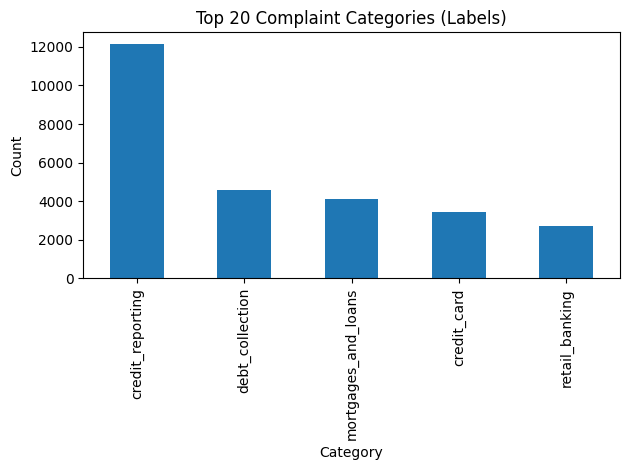

In [24]:
import matplotlib.pyplot as plt

top_n = 20
label_counts.head(top_n).plot(kind="bar")
plt.title(f"Top {top_n} Complaint Categories (Labels)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [25]:
df["raw_len"] = df["text"].astype(str).str.split().apply(len)
df["clean_len"] = df["clean_text"].astype(str).str.split().apply(len)

print(df[["raw_len", "clean_len"]].describe(percentiles=[.5, .75, .9, .95, .99]))


            raw_len     clean_len
count  26993.000000  26993.000000
mean      91.683955     91.683955
std      117.984367    117.984367
min        1.000000      1.000000
50%       59.000000     59.000000
75%      109.000000    109.000000
90%      193.000000    193.000000
95%      271.000000    271.000000
99%      552.000000    552.000000
max     2568.000000   2568.000000


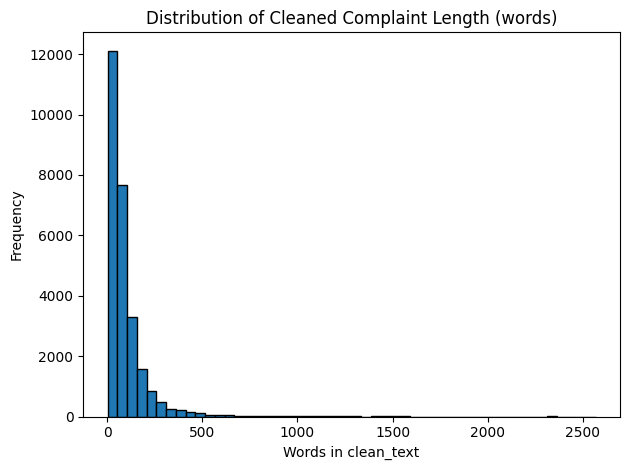

In [26]:
import matplotlib.pyplot as plt

df["clean_len"].plot(kind="hist", bins=50,edgecolor = 'black')
plt.title("Distribution of Cleaned Complaint Length (words)")
plt.xlabel("Words in clean_text")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [27]:
print("Very short (<= 5 words):", (df["clean_len"] <= 5).sum())
print("Very long (>= 300 words):", (df["clean_len"] >= 300).sum())

df.sort_values("clean_len").head(3)[["label", "clean_len", "clean_text"]]

Very short (<= 5 words): 348
Very long (>= 300 words): 1112


,label,clean_len,clean_text
875,credit_reporting,1,account
12596,credit_reporting,1,inquire
12741,retail_banking,1,dismissed


In [28]:
from collections import Counter

words = " ".join(df["clean_text"].astype(str)).split()
counter = Counter(words)

print("Total tokens:", len(words))
print("Unique tokens:", len(counter))
print("\nTop 25 words:", counter.most_common(25))


Total tokens: 2474825
Unique tokens: 23879

Top 25 words: [('account', 57186), ('credit', 53165), ('report', 27386), ('payment', 26746), ('information', 21569), ('loan', 16909), ('time', 16612), ('reporting', 15167), ('card', 15147), ('bank', 15006), ('company', 14862), ('would', 14770), ('debt', 13759), ('day', 12786), ('received', 11434), ('date', 10964), ('letter', 10937), ('never', 10844), ('call', 10485), ('number', 10245), ('due', 10203), ('told', 10203), ('consumer', 10105), ('collection', 10079), ('month', 9911)]


In [29]:
from collections import Counter

top_labels = df["label"].value_counts().head(3).index.tolist()

for lab in top_labels:
    words_lab = " ".join(df.loc[df["label"] == lab, "clean_text"].astype(str)).split()
    print("Label:", lab, "-Samples:", (df["label"] == lab).sum())
    print("Top 20 words:", Counter(words_lab).most_common(20))


Label: credit_reporting -Samples: 12148
Top 20 words: [('credit', 32947), ('account', 29863), ('report', 20575), ('information', 13709), ('reporting', 12197), ('payment', 9112), ('date', 7109), ('consumer', 6639), ('dispute', 5933), ('company', 5772), ('experian', 5579), ('bureau', 5495), ('agency', 5248), ('time', 5244), ('collection', 5195), ('number', 4990), ('inquiry', 4947), ('day', 4880), ('letter', 4778), ('balance', 4678)]
Label: debt_collection -Samples: 4562
Top 20 words: [('debt', 8361), ('credit', 7738), ('account', 7401), ('collection', 4427), ('report', 4044), ('company', 3809), ('information', 3482), ('payment', 2482), ('time', 2393), ('never', 2197), ('call', 2196), ('letter', 2177), ('received', 2087), ('reporting', 2009), ('agency', 1851), ('loan', 1800), ('consumer', 1752), ('sent', 1728), ('amount', 1714), ('would', 1689)]
Label: mortgages_and_loans -Samples: 4096
Top 20 words: [('loan', 10147), ('payment', 10079), ('mortgage', 6112), ('would', 4842), ('time', 4150)

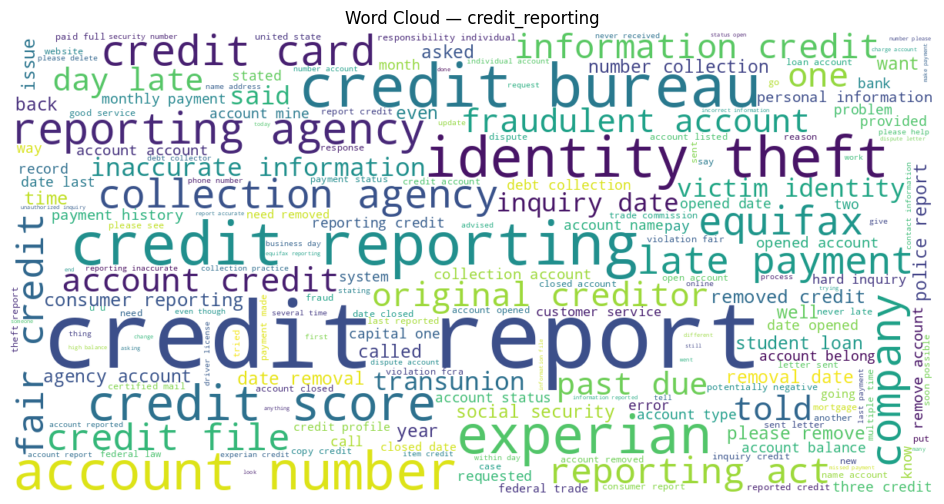

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

one_label = df["label"].value_counts().index[0]
text_blob = " ".join(df.loc[df["label"] == one_label, "clean_text"].astype(str))

wc = WordCloud(width=1200, height=600, background_color="white").generate(text_blob)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(f"Word Cloud — {one_label}")
plt.show()


In [31]:
# Train & Test
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (21594,)
Test size : (5399,)


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=5,
    max_features=50000
)

X_train_tfidf = tfidf.fit_transform(X_train.fillna(''))
X_test_tfidf = tfidf.transform(X_test.fillna(''))

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape :", X_test_tfidf.shape)

TF-IDF train shape: (21594, 50000)
TF-IDF test shape : (5399, 50000)


# NAIVE BAYES

In [33]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7782922763474718
                     precision    recall  f1-score   support

        credit_card       0.81      0.62      0.70       692
   credit_reporting       0.73      0.95      0.83      2430
    debt_collection       0.92      0.45      0.61       912
mortgages_and_loans       0.79      0.83      0.81       819
     retail_banking       0.93      0.66      0.77       546

           accuracy                           0.78      5399
          macro avg       0.84      0.70      0.74      5399
       weighted avg       0.80      0.78      0.77      5399



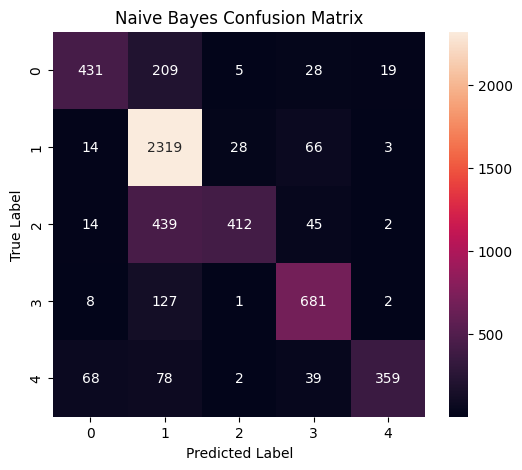

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# RANDOM fOREST

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.6443785886275236
                     precision    recall  f1-score   support

        credit_card       0.85      0.26      0.40       692
   credit_reporting       0.57      0.99      0.72      2430
    debt_collection       0.96      0.22      0.36       912
mortgages_and_loans       0.88      0.57      0.70       819
     retail_banking       0.93      0.41      0.57       546

           accuracy                           0.64      5399
          macro avg       0.84      0.49      0.55      5399
       weighted avg       0.76      0.64      0.60      5399



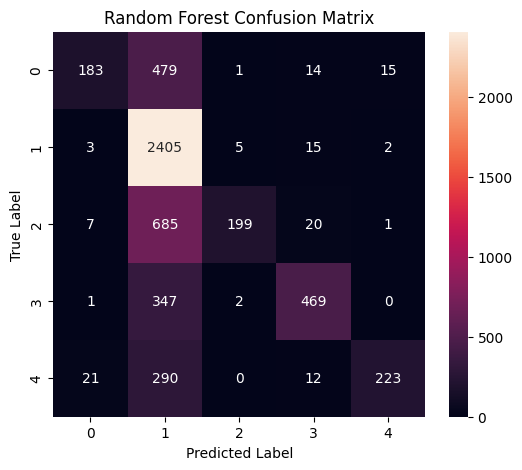

In [37]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## SVM

In [38]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


Linear SVM Accuracy: 0.851639192443045
                     precision    recall  f1-score   support

        credit_card       0.79      0.78      0.78       692
   credit_reporting       0.88      0.90      0.89      2430
    debt_collection       0.80      0.78      0.79       912
mortgages_and_loans       0.86      0.85      0.86       819
     retail_banking       0.87      0.85      0.86       546

           accuracy                           0.85      5399
          macro avg       0.84      0.83      0.84      5399
       weighted avg       0.85      0.85      0.85      5399



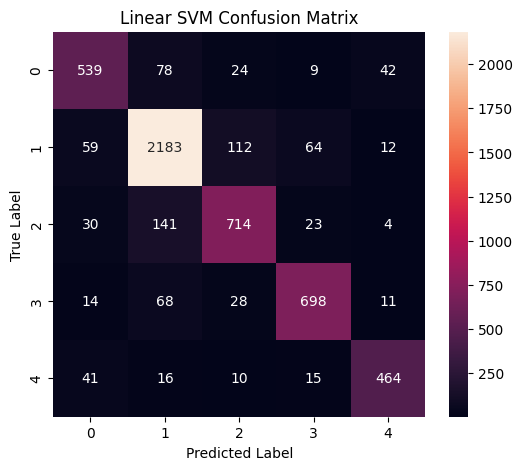

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## COMPARISION OF ALL MODELS

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# List to store results for each model
all_results = []

# Naive Bayes
all_results.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred_nb),
    "Precision": precision_score(y_test, y_pred_nb, average="weighted"),
    "Recall": recall_score(y_test, y_pred_nb, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred_nb, average="weighted")
})

# Random Forest
all_results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, average="weighted"),
    "Recall": recall_score(y_test, rf_pred, average="weighted"),
    "F1 Score": f1_score(y_test, rf_pred, average="weighted")
})

# Linear SVM
all_results.append({
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm, average="weighted"),
    "Recall": recall_score(y_test, y_pred_svm, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred_svm, average="weighted")
})

results_df = pd.DataFrame(all_results)

print(results_df.sort_values(by="Accuracy", ascending=False))

           Model  Accuracy  Precision    Recall  F1 Score
2     Linear SVM  0.851639   0.851115  0.851639  0.851280
0    Naive Bayes  0.778292   0.802213  0.778292  0.766143
1  Random Forest  0.644379   0.756658  0.644379  0.600827


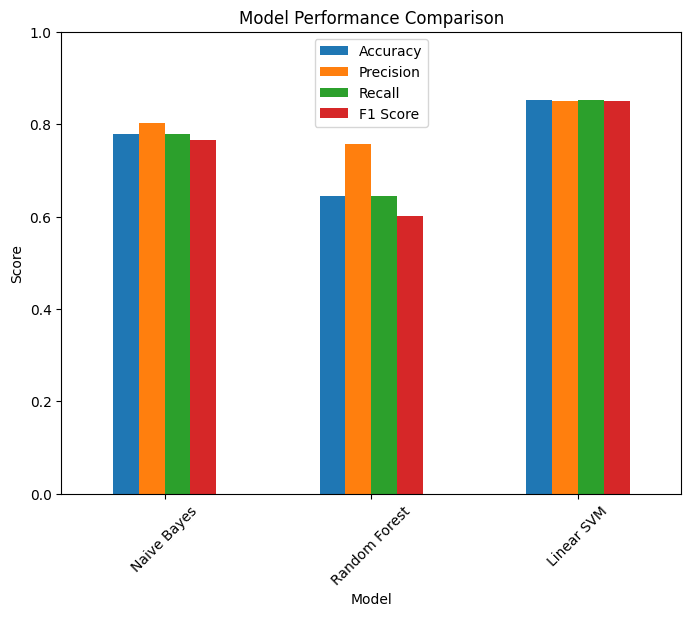

In [41]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(8,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.show()

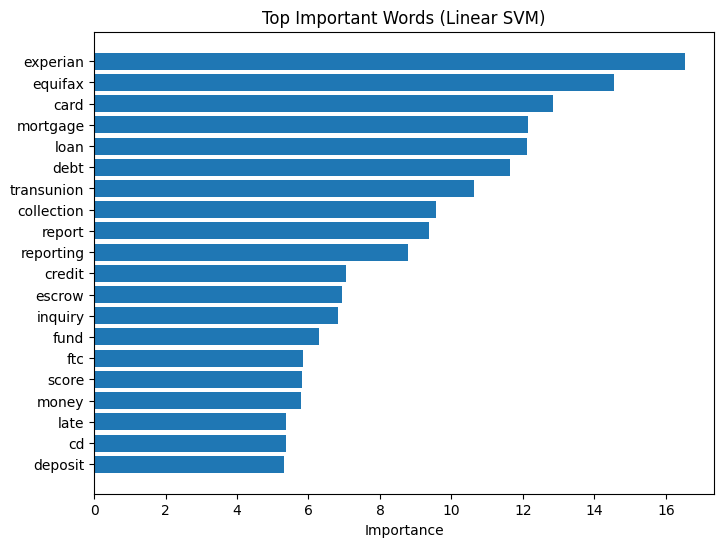

In [43]:
import numpy as np

feature_names = tfidf.get_feature_names_out()

# Calculate importance from coefficients for LinearSVC
importances = np.sum(np.abs(svm.coef_), axis=0)

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.title("Top Important Words (Linear SVM)")
plt.xlabel("Importance")

plt.show()

# TOP CATAGORIES

<Figure size 1200x1000 with 0 Axes>

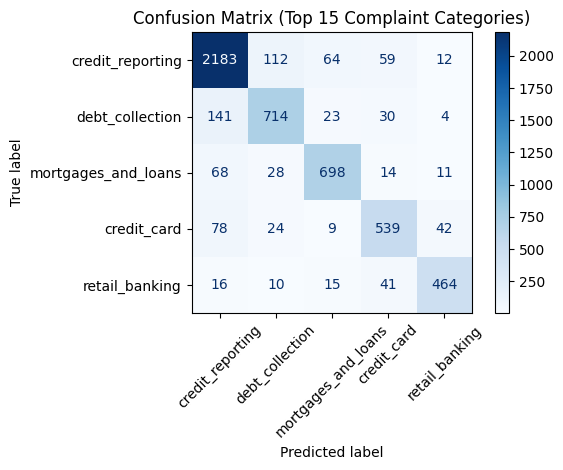

In [44]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_svm)
# get top 15 most frequent labels
top_labels = y_test.value_counts().head(15).index.tolist()

mask = y_test.isin(top_labels)
y_test_top = y_test[mask]
y_pred_top = pd.Series(y_pred_svm, index=y_test.index)[mask]

cm_top = confusion_matrix(y_test_top, y_pred_top, labels=top_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_top,
    display_labels=top_labels
)

plt.figure(figsize=(12, 10))
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix (Top 15 Complaint Categories)")
plt.tight_layout()
plt.show()


In [45]:
errors = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": y_pred_svm,
    "text": X_test
})

errors["is_error"] = errors["true_label"] != errors["predicted_label"]

print("Total test samples:", len(errors))
print("Total misclassified samples:", errors["is_error"].sum())


Total test samples: 5399
Total misclassified samples: 801


In [46]:
# TRUR LABEL VS PREDICTED LABEL
confusion_pairs = (
    errors[errors["is_error"]]
    .groupby(["true_label", "predicted_label"])
    .size()
    .sort_values(ascending=False)
)

confusion_pairs.head(10)


true_label           predicted_label    
debt_collection      credit_reporting       141
credit_reporting     debt_collection        112
credit_card          credit_reporting        78
mortgages_and_loans  credit_reporting        68
credit_reporting     mortgages_and_loans     64
                     credit_card             59
credit_card          retail_banking          42
retail_banking       credit_card             41
debt_collection      credit_card             30
mortgages_and_loans  debt_collection         28
dtype: int64

In [47]:
errors[errors["is_error"]].sample(5)[
    ["true_label", "predicted_label", "text"]
]


,true_label,predicted_label,text
21191,mortgages_and_loans,credit_reporting,hi loan number loan care company saw credit re...
19370,debt_collection,credit_reporting,hello way company investigated insurance utili...
25981,credit_card,credit_reporting,applied bankcard umb bank received letter deni...
743,credit_reporting,credit_card,account closed paid account full due hardship ...
8256,debt_collection,credit_reporting,cbe group located ia violation fair credit rep...


In [48]:
class_accuracy = (
    errors.assign(correct=~errors["is_error"])
    .groupby("true_label")["correct"]
    .mean()
    .sort_values()
)

class_accuracy.head(10)


,correct
true_label,
credit_card,0.778902
debt_collection,0.782895
retail_banking,0.849817
mortgages_and_loans,0.852259
credit_reporting,0.898354
